# Laboratorio Nro 01 - Regresión lineal

In [3]:
# Importación de librerías necesarias
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D

# Llama a matplotlib para embeber gráficas dentro de los cuadernillos
%matplotlib inline

In [2]:
from google.colab import drive
drive.mount("/content/gdrive")

Mounted at /content/gdrive


## 2 Regresión lineal con multiples variables

Se implementa la regresion lineal multivariable para predecir el precio de las casas. El archivo `Datasets/ex1data2.txt` contiene un conjunto de entrenamiento de precios de casas en Portland, Oregon. La primera columna es el tamaño de la casa en metros cuadrados, la segunda columna es el numero de cuartos, y la tercera columna es el precio de la casa.

<a id="section4"></a>
### 2.1 Normalización de caracteristicas

Al visualizar los datos se puede observar que las caracteristicas tienen diferentes magnitudes, por lo cual se debe transformar cada valor en una escala de valores similares, esto con el fin de que el descenso por el gradiente pueda converger mas rapidamente.

In [4]:
# Cargar datos
data = pd.read_csv('NYC.csv')

# Preprocesamiento para asegurar m >= 10000 y n >= 10
data = data.sample(n=20000, random_state=42).reset_index(drop=True)
data['pickup_datetime'] = pd.to_datetime(data['pickup_datetime'])
data['pickup_hour'] = data['pickup_datetime'].dt.hour
data['pickup_dayofweek'] = data['pickup_datetime'].dt.dayofweek
data['pickup_month'] = data['pickup_datetime'].dt.month
data['store_and_fwd_flag'] = data['store_and_fwd_flag'].map({'Y': 1, 'N': 0})

# Asignar a X las 10 características y a y la duración del viaje
X = data[['vendor_id', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 
          'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
          'pickup_hour', 'pickup_dayofweek', 'pickup_month']].values
y = data['trip_duration'].values
m = y.size
print(m)

# imprimir algunos puntos de datos
# Mantenemos el formato de tu imagen mostrando las dos primeras columnas de X y la y
print('{:>8s}{:>8s}{:>10s}'.format('X[:,0]', 'X[:, 1]', 'y'))
print('-'*26)
for i in range(10):
    print('{:8.0f}{:8.0f}{:10.0f}'.format(X[i, 0], X[i, 1], y[i]))

20000
  X[:,0] X[:, 1]         y
--------------------------
       2       1      1040
       2       1       827
       2       5       614
       2       2       867
       1       4      4967
       2       3       374
       2       1      1252
       1       1       148
       2       1      1499
       1       1      1017


In [5]:
def featureNormalize(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    
    # Evitar divisiones por cero en caso de que alguna característica sea idéntica en todas las filas
    sigma[sigma == 0] = 1 
    
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

# Normalizar los datos
X_norm, mu, sigma = featureNormalize(X)

# Añadir el término de intersección (Columna de unos para X0)
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

print("Matriz X normalizada y con término de intersección:")
print(X[:3, :]) # Mostrar solo las primeras 3 filas

Matriz X normalizada y con término de intersección:
[[ 1.00000000e+00  9.33693137e-01 -5.04733111e-01 -3.16638244e-01
  -5.35612837e-01 -1.91242191e-01  2.60393881e-01 -7.57144389e-02
  -1.02820202e+00 -5.39674791e-01  1.48198952e+00]
 [ 1.00000000e+00  9.33693137e-01 -5.04733111e-01 -1.30583261e-01
   4.74028409e-01 -4.98475804e-01 -6.74762730e-02 -7.57144389e-02
  -2.46822243e-01  1.50862122e+00  2.89481356e-01]
 [ 1.00000000e+00  9.33693137e-01  2.55356037e+00 -4.05535551e-01
  -2.35445559e-01 -2.12744745e-03 -1.03552601e-01 -7.57144389e-02
  -1.80958179e+00  1.50862122e+00  1.48198952e+00]]


In [6]:
# llama featureNormalize con los datos cargados
X_norm, mu, sigma = featureNormalize(X)

print(X)
print('Media calculada:', mu)
print('Desviación estandar calculada:', sigma)
print(X_norm)

[[ 1.          0.93369314 -0.50473311 ... -1.02820202 -0.53967479
   1.48198952]
 [ 1.          0.93369314 -0.50473311 ... -0.24682224  1.50862122
   0.28948136]
 [ 1.          0.93369314  2.55356037 ... -1.80958179  1.50862122
   1.48198952]
 ...
 [ 1.         -1.07101569 -0.50473311 ... -0.71565011 -1.05174879
   1.48198952]
 [ 1.          0.93369314  0.25984026 ... -0.4030982   0.48447321
   1.48198952]
 [ 1.         -1.07101569 -0.50473311 ... -0.71565011  0.48447321
   0.88573544]]
Media calculada: [ 1.00000000e+00  1.81898940e-16 -4.51194637e-17  9.77589565e-14
  8.10103984e-14  2.27205987e-13 -3.23332472e-14 -2.18491891e-17
  3.44613227e-17 -3.55271368e-17  4.12114787e-17]
Desviación estandar calculada: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
[[ 0.          0.93369314 -0.50473311 ... -1.02820202 -0.53967479
   1.48198952]
 [ 0.          0.93369314 -0.50473311 ... -0.24682224  1.50862122
   0.28948136]
 [ 0.          0.93369314  2.55356037 ... -1.80958179  1.50862122
   1.48198952]
 .

In [7]:
# Añade el termino de interseccion a X
# (Columna de unos para X0)
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

In [8]:
print(X)

[[ 1.          0.          0.93369314 ... -1.02820202 -0.53967479
   1.48198952]
 [ 1.          0.          0.93369314 ... -0.24682224  1.50862122
   0.28948136]
 [ 1.          0.          0.93369314 ... -1.80958179  1.50862122
   1.48198952]
 ...
 [ 1.          0.         -1.07101569 ... -0.71565011 -1.05174879
   1.48198952]
 [ 1.          0.          0.93369314 ... -0.4030982   0.48447321
   1.48198952]
 [ 1.          0.         -1.07101569 ... -0.71565011  0.48447321
   0.88573544]]


<a id="section5"></a>
### 2.2 Descenso por el gradiente


In [9]:
def computeCostMulti(X, y, theta):
    # Inicializa algunos valores utiles
    m = y.shape[0] # numero de ejemplos de entrenamiento

    J = 0

    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J


In [10]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):

    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente

    theta = theta.copy()

    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

#### 3.2.1 Seleccionando coheficientes de aprendizaje


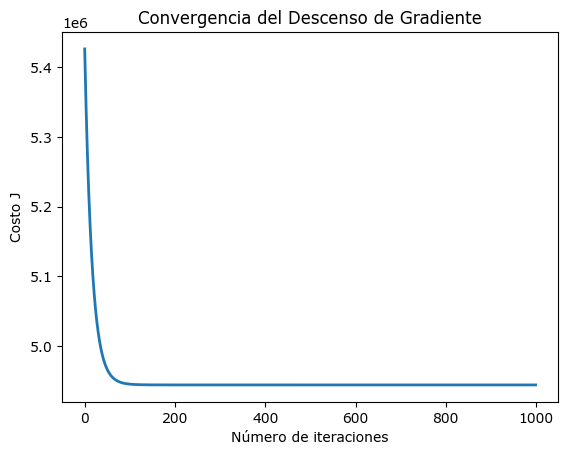

Parámetros theta óptimos encontrados:
 [ 959.40735       0.          106.83666639   24.89115308  193.81064911
  -45.08085569  128.98017958 -126.98168387   11.91595345  -15.73053441
  -45.9059693    23.74881552]


In [12]:
# Configurar hiperparámetros
alpha = 0.03
num_iters = 1000

# Inicializar theta (11 valores: 10 características + 1 término de sesgo)
theta = np.zeros(X.shape[1])

# Ejecutar el entrenamiento
theta, J_history = gradientDescentMulti(X, y, theta, alpha, num_iters)

# Graficar la convergencia del costo para asegurar que el error se minimiza
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del Descenso de Gradiente')
pyplot.show()

print('Parámetros theta óptimos encontrados:\n', theta)

In [13]:
# Vector con: [1, vendor_id, passenger_count, pick_lon, pick_lat, drop_lon, drop_lat, flag, hour, day, month]
X_array = [1, 1, 2, -73.98, 40.75, -73.99, 40.76, 0, 14, 2, 5]

# Normalizar solo las características (del índice 1 en adelante)
X_array[1:] = (X_array[1:] - mu[1:]) / sigma[1:]

In [18]:
# Calcular la duración estimada (y = theta * X)
duracion_segundos = np.dot([1, 0] + X_array[1:], theta)

print(f'\nLa duración predecida para este viaje es: {duracion_segundos:.2f} segundos')


La duración predecida para este viaje es: -29971.44 segundos


<a id="section7"></a>
### 2.3 Ecuacion de la Normal

Una manera de calcular rapidamente el modelo de una regresion lineal es:

$$ \theta = \left( X^T X\right)^{-1} X^T\vec{y}$$

Utilizando esta formula no requiere que se escale ninguna caracteristica, y se obtendra una solucion exacta con un solo calculo: no hay “bucles de convergencia” como en el descenso por el gradiente.

Primero se recargan los datos para garantizar que las variables no esten modificadas. Recordar que no es necesario escalar las caracteristicas, se debe agregar la columna de unos a la matriz $X$ para tener el termino de intersección($\theta_0$).

In [21]:
# 1. Cargar el dataset (Asegúrate de que el nombre sea correcto)
data = pd.read_csv('NYC.csv') 

# 2. Preprocesamiento rápido (m >= 10000)
data = data.sample(n=20000, random_state=42).reset_index(drop=True)

# 3. CORRECCIÓN: Usar .iloc para slicing en Pandas
# Seleccionamos las primeras 10 columnas para X (n=10) y la columna 10 para y
X = data.iloc[:, :10].values  # .values lo convierte a matriz de NumPy
y = data.iloc[:, 10].values   # La columna 10 es la variable objetivo
m = y.size

print(f"Total de registros cargados (m): {m}")

# 4. Concatenar la columna de unos (X0)
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

Total de registros cargados (m): 20000


In [22]:
def normalEqn(X, y):
    """
    Calcula la solución óptima de theta de forma directa.
    """
    theta = np.zeros(X.shape[1])
    # Ecuación: theta = (X^T * X)^-1 * X^T * y
    theta = np.dot(np.dot(np.linalg.inv(np.dot(X.T, X)), X.T), y)
    return theta

In [27]:
# Calcula los parametros con la ecuación de la normal
# (Asegúrate de estar usando la matriz X original con la columna de unos, SIN normalizar)
theta_normal = np.dot(np.dot(np.linalg.pinv(np.dot(X.T, X)), X.T), y)

# Muestra los resultados obtenidos a partir de la aplicación de la ecuación de la normal
print('Theta calculado a partir de la ecuación de la normal: {:s}'.format(str(theta_normal)))

# Estimar la duración para un viaje de taxi ficticio con nuestras 10 características:
# Orden: [X0, vendor_id, passenger_count, pick_lon, pick_lat, drop_lon, drop_lat, flag, hour, day, month]
X_array = [1, 1, 2, -73.98, 40.75, -73.99, 40.76, 0, 14, 2, 5]

# Realizar la predicción mediante el producto punto (sin necesidad de normalizar X_array)
duracion_estimada = np.dot([1, 0] + X_array[1:], theta_normal)

# Imprimir el resultado final en segundos
print('Duración predecida para el viaje de taxi (usando la ecuación de la normal): {:.0f} segundos'.format(duracion_estimada))

Theta calculado a partir de la ecuación de la normal: [ 9.59407350e+02  4.22451011e-14  1.06836666e+02  2.48911533e+01
  1.93810653e+02 -4.50808477e+01  1.28980178e+02 -1.26981691e+02
  1.19159537e+01 -1.57305347e+01 -4.59059687e+01  2.37488154e+01]
Duración predecida para el viaje de taxi (usando la ecuación de la normal): -29971 segundos
